# My Strava Running Analysis

An exploration of my personal running data from 2018 to 2026, using Python and pandas.

**Questions explored:**
- How has my total running distance changed each year?
- Has my cardiovascular fitness improved over time (heart rate at similar pace)?


## Setup

Loading libraries and importing the data.

In [138]:
import pandas as pd
df = pd.read_csv("activities.csv")

In [139]:
df.head()

,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,Recovery,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Total Sets,Total Reps,Media
0,19583603020,"Aug 3, 2026, 1:41:29 PM",Test2,Run,NaN,2860,5.35,166.0,53.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19563975130,"Aug 2, 2026, 2:41:52 AM",Morning Weight Training,Weight Training,NaN,3798,0.00,155.0,12.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,68.0,NaN
2,19529493244,"Jul 30, 2026, 1:34:35 PM",First run walk to test injured left knee,Run,NaN,1542,3.17,175.0,31.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19509543914,"Jul 29, 2026, 2:49:21 AM",Morning Weight Training,Weight Training,NaN,4846,0.00,145.0,12.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,102.0,NaN
4,19494047004,"Jul 28, 2026, 1:51:30 AM",Morning Weight Training,Weight Training,NaN,3193,0.00,170.0,14.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,60.0,NaN


In [140]:
df.head

<bound method NDFrame.head of      Activity ID             Activity Date  \
0    19583603020   Aug 3, 2026, 1:41:29 PM   
1    19563975130   Aug 2, 2026, 2:41:52 AM   
2    19529493244  Jul 30, 2026, 1:34:35 PM   
3    19509543914  Jul 29, 2026, 2:49:21 AM   
4    19494047004  Jul 28, 2026, 1:51:30 AM   
..           ...                       ...   
377   3370239068  Apr 28, 2020, 2:23:04 PM   
378   3102060131  Feb 15, 2020, 3:00:04 PM   
379   3099028034  Feb 14, 2020, 2:19:31 PM   
380   3098975339  Sep 27, 2019, 2:21:20 PM   
381   1496252454  Apr 8, 2018, 10:31:07 AM   

                                Activity Name    Activity Type  \
0                                       Test2              Run   
1                     Morning Weight Training  Weight Training   
2    First run walk to test injured left knee              Run   
3                     Morning Weight Training  Weight Training   
4                     Morning Weight Training  Weight Training   
..                   

In [141]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['Activity ID', 'Activity Date', 'Activity Name', 'Activity Type',
       'Activity Description', 'Elapsed Time', 'Distance', 'Max Heart Rate',
       'Relative Effort', 'Commute',
       ...
       'Recovery', 'With Pet', 'Competition', 'Long Run', 'For a Cause',
       'With Kid', 'Downhill Distance', 'Total Sets', 'Total Reps', 'Media'],
      dtype='str', length=103)>

In [142]:
df.shape

(382, 103)

In [143]:
runs = df[df["Activity Type"] == "Run"]
runs.shape

(203, 103)

In [144]:
runs[["Activity Date", "Distance", "Moving Time", "Average Speed", "Average Heart Rate", "Elevation Gain"]].head(10)

,Activity Date,Distance,Moving Time,Average Speed,Average Heart Rate,Elevation Gain
0,"Aug 3, 2026, 1:41:29 PM",5.35,2860.0,1.872,153.0,3.0
2,"Jul 30, 2026, 1:34:35 PM",3.17,1542.0,2.060,156.0,1.0
18,"Jun 17, 2026, 12:01:40 PM",4.05,1328.0,3.053,171.0,1.0
22,"Jun 13, 2026, 11:27:39 PM",11.47,5370.0,2.136,163.0,47.0
27,"Jun 6, 2026, 10:50:02 AM",3.00,1098.0,2.738,166.0,4.0
31,"Jun 2, 2026, 10:11:45 AM",5.29,1631.0,3.244,181.0,2.0
34,"May 30, 2026, 12:02:04 AM",10.00,4009.0,2.496,153.0,0.0
37,"May 22, 2026, 12:52:29 AM",2.40,597.0,4.025,184.0,0.0
40,"May 12, 2026, 10:03:09 AM",4.75,1565.0,3.035,170.0,0.0
44,"May 9, 2026, 2:35:53 PM",6.13,2820.0,2.174,147.0,3.0


In [145]:
runs = runs.copy()
runs["Pace (min/km)"] = (runs["Moving Time"] / 60 / runs["Distance"])
runs[["Activity Date", "Distance", "Pace (min/km)"]].head(10)

,Activity Date,Distance,Pace (min/km)
0,"Aug 3, 2026, 1:41:29 PM",5.35,8.909657
2,"Jul 30, 2026, 1:34:35 PM",3.17,8.107256
18,"Jun 17, 2026, 12:01:40 PM",4.05,5.465021
22,"Jun 13, 2026, 11:27:39 PM",11.47,7.802964
27,"Jun 6, 2026, 10:50:02 AM",3.00,6.100000
31,"Jun 2, 2026, 10:11:45 AM",5.29,5.138626
34,"May 30, 2026, 12:02:04 AM",10.00,6.681667
37,"May 22, 2026, 12:52:29 AM",2.40,4.145833
40,"May 12, 2026, 10:03:09 AM",4.75,5.491228
44,"May 9, 2026, 2:35:53 PM",6.13,7.667210


In [146]:
runs = runs.copy()
runs["Pace (min/km)"] = (runs["Moving Time"] / 60) / runs["Distance"]
runs[["Activity Date", "Distance", "Pace (min/km)"]].head(10)


,Activity Date,Distance,Pace (min/km)
0,"Aug 3, 2026, 1:41:29 PM",5.35,8.909657
2,"Jul 30, 2026, 1:34:35 PM",3.17,8.107256
18,"Jun 17, 2026, 12:01:40 PM",4.05,5.465021
22,"Jun 13, 2026, 11:27:39 PM",11.47,7.802964
27,"Jun 6, 2026, 10:50:02 AM",3.00,6.100000
31,"Jun 2, 2026, 10:11:45 AM",5.29,5.138626
34,"May 30, 2026, 12:02:04 AM",10.00,6.681667
37,"May 22, 2026, 12:52:29 AM",2.40,4.145833
40,"May 12, 2026, 10:03:09 AM",4.75,5.491228
44,"May 9, 2026, 2:35:53 PM",6.13,7.667210


In [147]:
runs[runs["Distance"] > 5]


,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Total Sets,Total Reps,Media,Pace (min/km)
0,19583603020,"Aug 3, 2026, 1:41:29 PM",Test2,Run,NaN,2860,5.35,166.0,53.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.909657
22,18910531705,"Jun 13, 2026, 11:27:39 PM",Morning Run,Run,NaN,5436,11.47,184.0,136.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.802964
31,18753805348,"Jun 2, 2026, 10:11:45 AM",Evening Run,Run,5min warm up jog\n1km x 4 sets interval\nCool ...,2404,5.29,203.0,80.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.138626
34,18708940415,"May 30, 2026, 12:02:04 AM",Morning Run,Run,IPPT over,4009,10.00,190.0,70.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.681667
44,18440598147,"May 9, 2026, 2:35:53 PM",Night Run,Run,NaN,2823,6.13,158.0,28.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.667210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,10152286881,"Nov 3, 2023, 10:15:47 AM",Evening Run,Run,NaN,2835,7.02,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.622032
233,10135364625,"Oct 31, 2023, 10:06:59 AM",Evening Run,Run,NaN,3680,7.98,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.831245
291,6701499424,"Feb 18, 2022, 1:31:04 PM",Chill night,Run,NaN,1878,5.09,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.054355
294,6635331559,"Feb 5, 2022, 2:24:27 PM",Chill,Run,NaN,2048,5.08,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.676509


In [148]:
runs [runs["Distance"] > 5]

,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Total Sets,Total Reps,Media,Pace (min/km)
0,19583603020,"Aug 3, 2026, 1:41:29 PM",Test2,Run,NaN,2860,5.35,166.0,53.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.909657
22,18910531705,"Jun 13, 2026, 11:27:39 PM",Morning Run,Run,NaN,5436,11.47,184.0,136.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.802964
31,18753805348,"Jun 2, 2026, 10:11:45 AM",Evening Run,Run,5min warm up jog\n1km x 4 sets interval\nCool ...,2404,5.29,203.0,80.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.138626
34,18708940415,"May 30, 2026, 12:02:04 AM",Morning Run,Run,IPPT over,4009,10.00,190.0,70.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.681667
44,18440598147,"May 9, 2026, 2:35:53 PM",Night Run,Run,NaN,2823,6.13,158.0,28.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.667210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,10152286881,"Nov 3, 2023, 10:15:47 AM",Evening Run,Run,NaN,2835,7.02,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.622032
233,10135364625,"Oct 31, 2023, 10:06:59 AM",Evening Run,Run,NaN,3680,7.98,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.831245
291,6701499424,"Feb 18, 2022, 1:31:04 PM",Chill night,Run,NaN,1878,5.09,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.054355
294,6635331559,"Feb 5, 2022, 2:24:27 PM",Chill,Run,NaN,2048,5.08,NaN,NaN,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.676509


In [149]:
runs["Activity Date"] = pd.to_datetime(runs["Activity Date"])
runs["Activity Date"].head()

/var/folders/96/cw2sj9d97pl5ym5y0__srzc00000gn/T/ipykernel_1160/1675081467.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  runs["Activity Date"] = pd.to_datetime(runs["Activity Date"])


0    2026-08-03 13:41:29
2    2026-07-30 13:34:35
18   2026-06-17 12:01:40
22   2026-06-13 23:27:39
27   2026-06-06 10:50:02
Name: Activity Date, dtype: datetime64[us]

In [150]:
runs["Year"] = runs["Activity Date"].dt.year

In [151]:
runs[["Activity Date", "Year"]].head()



,Activity Date,Year
0,2026-08-03 13:41:29,2026
2,2026-07-30 13:34:35,2026
18,2026-06-17 12:01:40,2026
22,2026-06-13 23:27:39,2026
27,2026-06-06 10:50:02,2026


In [152]:
runs[["Activity Date", "Year"]].head()


,Activity Date,Year
0,2026-08-03 13:41:29,2026
2,2026-07-30 13:34:35,2026
18,2026-06-17 12:01:40,2026
22,2026-06-13 23:27:39,2026
27,2026-06-06 10:50:02,2026


In [153]:
runs[["Activity Date", "Year"]].head()


,Activity Date,Year
0,2026-08-03 13:41:29,2026
2,2026-07-30 13:34:35,2026
18,2026-06-17 12:01:40,2026
22,2026-06-13 23:27:39,2026
27,2026-06-06 10:50:02,2026


In [154]:
runs.groupby("Year")["Distance"].sum()

Year
2018      3.68
2019      1.88
2020     47.09
2021     89.85
2022     61.19
2023    107.25
2024    194.32
2025    264.02
2026    208.15
Name: Distance, dtype: float64

## Analysis 1: Total Distance by Year

How many kilometres did I run each year? This shows the growth of my running habit from 2018 to 2026.


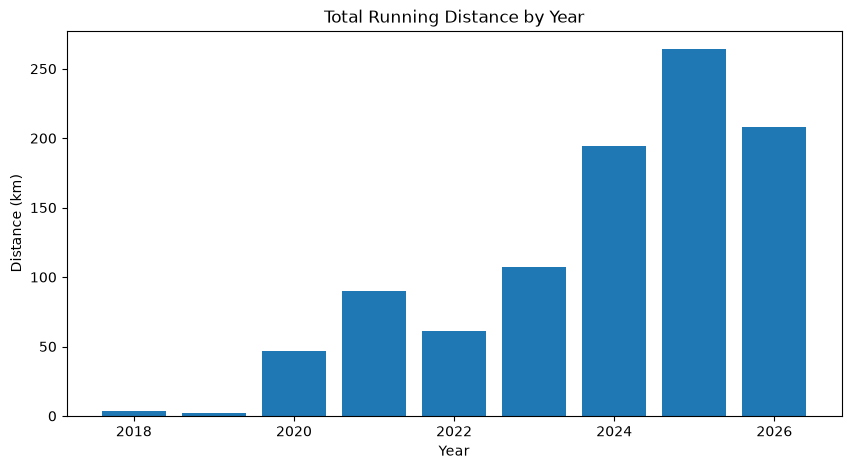

In [155]:
import matplotlib.pyplot as plt

yearly_distance = runs.groupby("Year")["Distance"].sum()

plt.figure(figsize=(10,5))
plt.bar(yearly_distance.index, yearly_distance.values)
plt.title("Total Running Distance by Year")
plt.xlabel("Year")
plt.ylabel("Distance (km)")
plt.show()

In [156]:
runs["Average Heart Rate"].isna().sum()

np.int64(143)

In [157]:
runs.groupby("Year")["Average Heart Rate"].count()

Year
2018     0
2019     0
2020     0
2021     0
2022     0
2023     0
2024     0
2025    22
2026    38
Name: Average Heart Rate, dtype: int64

In [158]:
runs["Pace (min/km)"].describe()


/Users/junlim/Desktop/Website Projects/Data Science Journey/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    203.000000
mean            inf
std             NaN
min        1.761397
25%        5.479419
50%        6.000000
75%        6.833348
max             inf
Name: Pace (min/km), dtype: float64

In [159]:
runs = runs[runs["Distance"] > 0].copy()
runs["Pace (min/km)"].describe()


count    196.000000
mean       6.248818
std        1.872415
min        1.761397
25%        5.463765
50%        5.982153
75%        6.703365
max       26.267606
Name: Pace (min/km), dtype: float64

In [160]:
similar_pace_runs = runs[(runs["Pace (min/km)"] > 5.5) & (runs["Pace (min/km)"] < 7.5)]


In [161]:
similar_pace_runs.shape

(116, 105)

In [162]:
similar_pace_runs.isna().sum()

Activity ID               0
Activity Date             0
Activity Name             0
Activity Type             0
Activity Description    114
                       ... 
Total Sets              116
Total Reps              116
Media                    90
Pace (min/km)             0
Year                      0
Length: 105, dtype: int64

In [163]:
similar_pace_runs["Average Heart Rate"].isna().sum()


np.int64(85)

In [164]:
hr_runs = similar_pace_runs.dropna(subset=["Average Heart Rate"]).copy()
hr_runs.shape


(31, 105)

In [165]:
hr_runs["Month"] = hr_runs["Activity Date"].dt.to_period("M")
hr_runs.groupby("Month")["Average Heart Rate"].mean()

Month
2025-10    176.5
2025-11    168.6
2025-12    178.6
2026-02    181.5
2026-03    172.0
2026-04    172.4
2026-05    164.5
2026-06    166.0
Freq: M, Name: Average Heart Rate, dtype: float64

## Analysis 2: Cardiovascular Fitness Over Time

Filtering to runs at a similar pace (5:30–7:30 min/km) to control for effort, then tracking how average heart rate has changed month by month. A declining heart rate at the same pace indicates improving fitness.


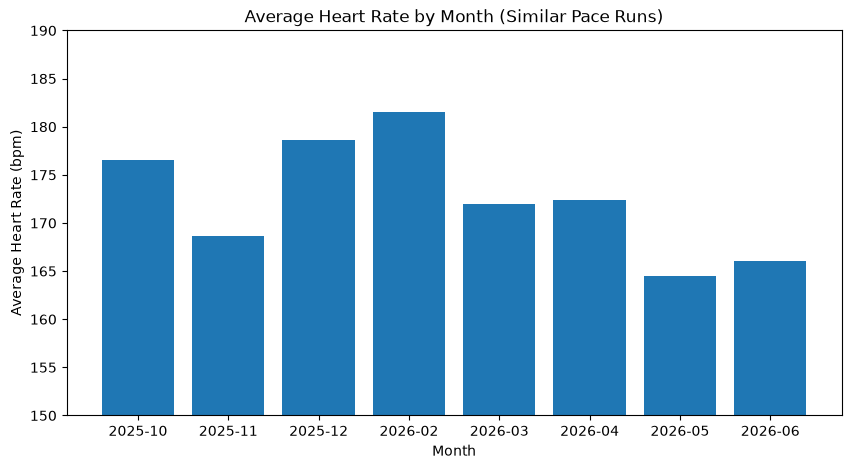

In [166]:
monthly_hr = hr_runs.groupby("Month")["Average Heart Rate"].mean()

plt.figure(figsize=(10, 5))
plt.bar(monthly_hr.index.astype(str), monthly_hr.values)
plt.title("Average Heart Rate by Month (Similar Pace Runs)")
plt.xlabel("Month")
plt.ylabel("Average Heart Rate (bpm)")
plt.ylim (150,190)
plt.show()


## Statistical Summary: Understanding my running data

Before drawing conclusions, it helps to understand the basic statistics behind the numbers

In [167]:
runs["Pace (min/km)"].describe()

count    196.000000
mean       6.248818
std        1.872415
min        1.761397
25%        5.463765
50%        5.982153
75%        6.703365
max       26.267606
Name: Pace (min/km), dtype: float64

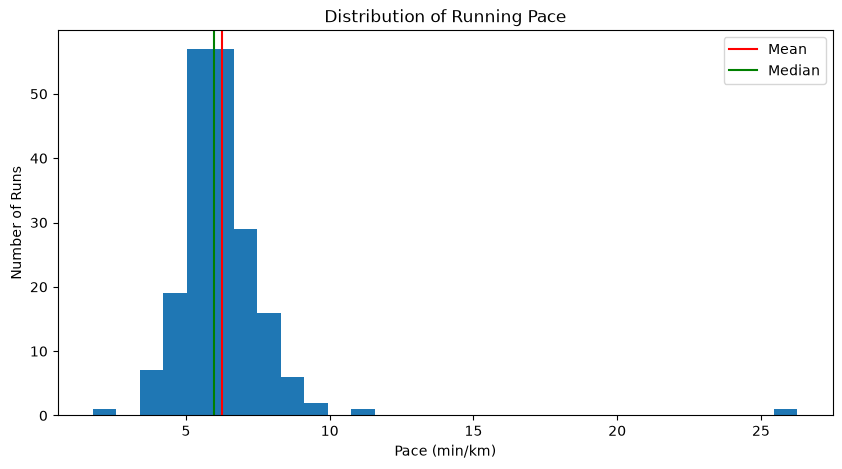

In [168]:
plt.figure(figsize=(10, 5))
plt.hist(runs["Pace (min/km)"], bins=30)
plt.axvline(runs["Pace (min/km)"].mean(), color='red', label='Mean')
plt.axvline(runs["Pace (min/km)"].median(), color='green', label='Median')
plt.title("Distribution of Running Pace")
plt.xlabel("Pace (min/km)")
plt.ylabel("Number of Runs")
plt.legend()
plt.show()


In [169]:
mean_pace = runs["Pace (min/km)"].mean()
std_pace = runs["Pace (min/km)"].std()

print(f"Mean: {mean_pace:.2f} min/km")
print(f"Standard deviation: {std_pace:.2f} min/km")
print(f"One std below mean: {mean_pace - std_pace:.2f} min/km")
print(f"One std above mean: {mean_pace + std_pace:.2f} min/km")


Mean: 6.25 min/km
Standard deviation: 1.87 min/km
One std below mean: 4.38 min/km
One std above mean: 8.12 min/km


In [170]:
in_range = runs [(runs["Pace (min/km)"] > 4.38) & (runs["Pace (min/km)"] < 8.12)] 
percentage = len(in_range) / len(runs) * 100
print(percentage)

87.75510204081633


## Understanding Correlation

Does running further mean the pace gets slower?

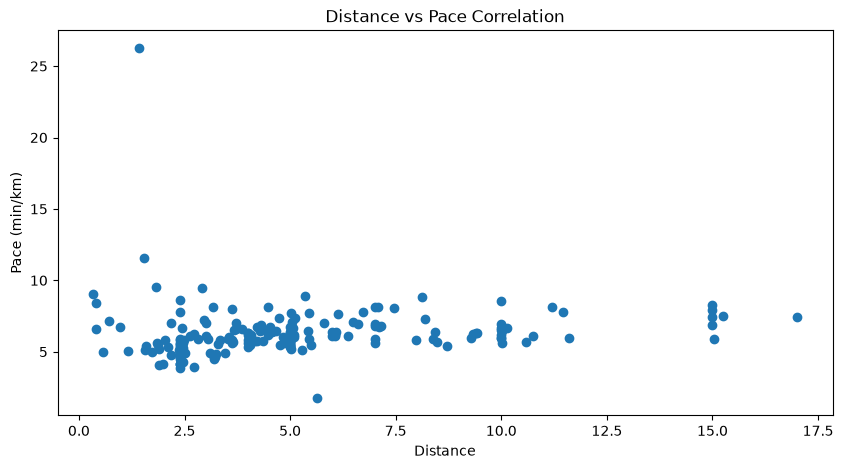

In [171]:
plt.figure(figsize=(10,5))
plt.scatter(runs["Distance"], runs["Pace (min/km)"])
plt.xlabel("Distance")
plt.ylabel("Pace (min/km)")
plt.title("Distance vs Pace Correlation")
plt.show()

Interesting, distance and pace isnt directly correlated as we expected. Lets try this code to get correlation values:

In [172]:
correlation = runs["Distance"].corr(runs["Pace (min/km)"])
print(f"Correlation: {correlation:.2f}")

Correlation: 0.13


This is known as the Pearson Correlation Coefficient

## First Taste of Linear Regression

Can I predict my pace from my heart rate?

In [173]:
correlation = runs["Pace (min/km)"].corr(runs["Average Heart Rate"]) 
print(f"Correlation: {correlation:.2f}")


Correlation: -0.57


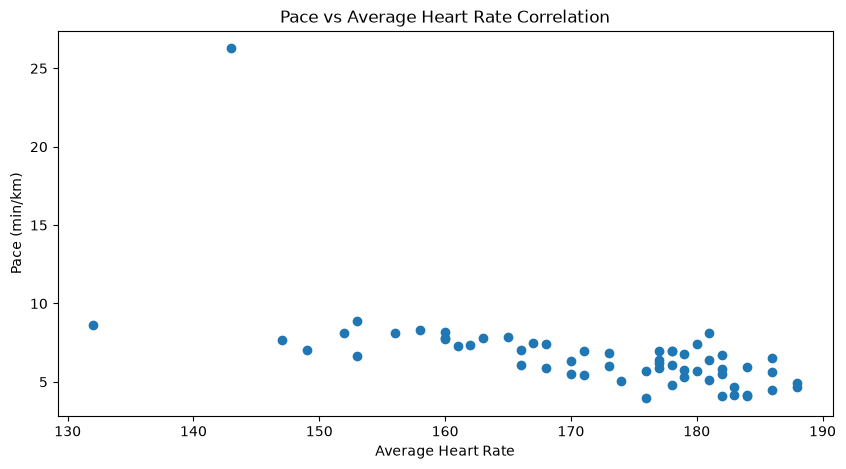

In [174]:
plt.figure(figsize = (10,5))
plt.scatter(runs["Average Heart Rate"], runs["Pace (min/km)"])
plt.xlabel("Average Heart Rate")
plt.ylabel("Pace (min/km)")
plt.title("Pace vs Average Heart Rate Correlation")
plt.show()

From the scatter plot, we can see that there is a slight downward trend, which reinforces the -0.57 correlation coefficient. Next, we will fit a straight line through these dots.


In [175]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [176]:
model_data = runs.dropna(subset=["Average Heart Rate", "Pace (min/km)"]).copy()
print(model_data.shape)

(60, 105)


In [177]:

X = model_data[["Average Heart Rate"]]
y = model_data["Pace (min/km)"]

model = LinearRegression()
model.fit(X,y)

print(f"Slope: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")



Slope: -0.1324
Intercept: 29.4375


** What exactly do these values mean?

Remember y = mx + c? Since these is linear regression, we can use the linear equation
y = Pace, m = Gradient, x = Heart Rate, c = Intercept
Pace = -0.1324(Heart Rate) + 29.4375

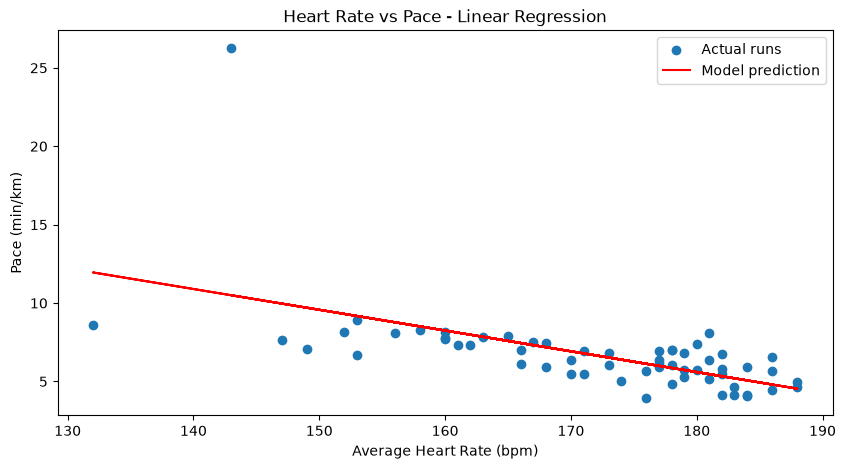

In [179]:
plt.figure(figsize=(10,5))
plt.scatter(model_data["Average Heart Rate"], model_data["Pace (min/km)"], label="Actual runs")
plt.plot(model_data["Average Heart Rate"], model.predict(X), color="red", label="Model prediction")
plt.xlabel("Average Heart Rate (bpm)")
plt.ylabel("Pace (min/km)")
plt.title("Heart Rate vs Pace - Linear Regression")
plt.legend()
plt.show()

## Now we can use the model we just created to predict

In [181]:
model.predict([[160]])

/Users/junlim/Desktop/Website Projects/Data Science Journey/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([8.24590557])

In [182]:
model.predict([[180]])

/Users/junlim/Desktop/Website Projects/Data Science Journey/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([5.5969614])